In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
path = "piezometros/"
# Diccionario para almacenar los dataframes
piezometros = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Piezometrico.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}"
                # Almacenar el dataframe en el diccionario
                piezometros[nombre_df] = df

for key, df in piezometros.items():
    df['Date'] = pd.to_datetime(df['Date'])
    piezometros[key] = df.set_index("Date") 

In [29]:
for key, df in piezometros.items():
    piezometros[key] = df.resample('D').mean()
    piezometros[key] = df.reset_index() 

### Todos los piezómetros

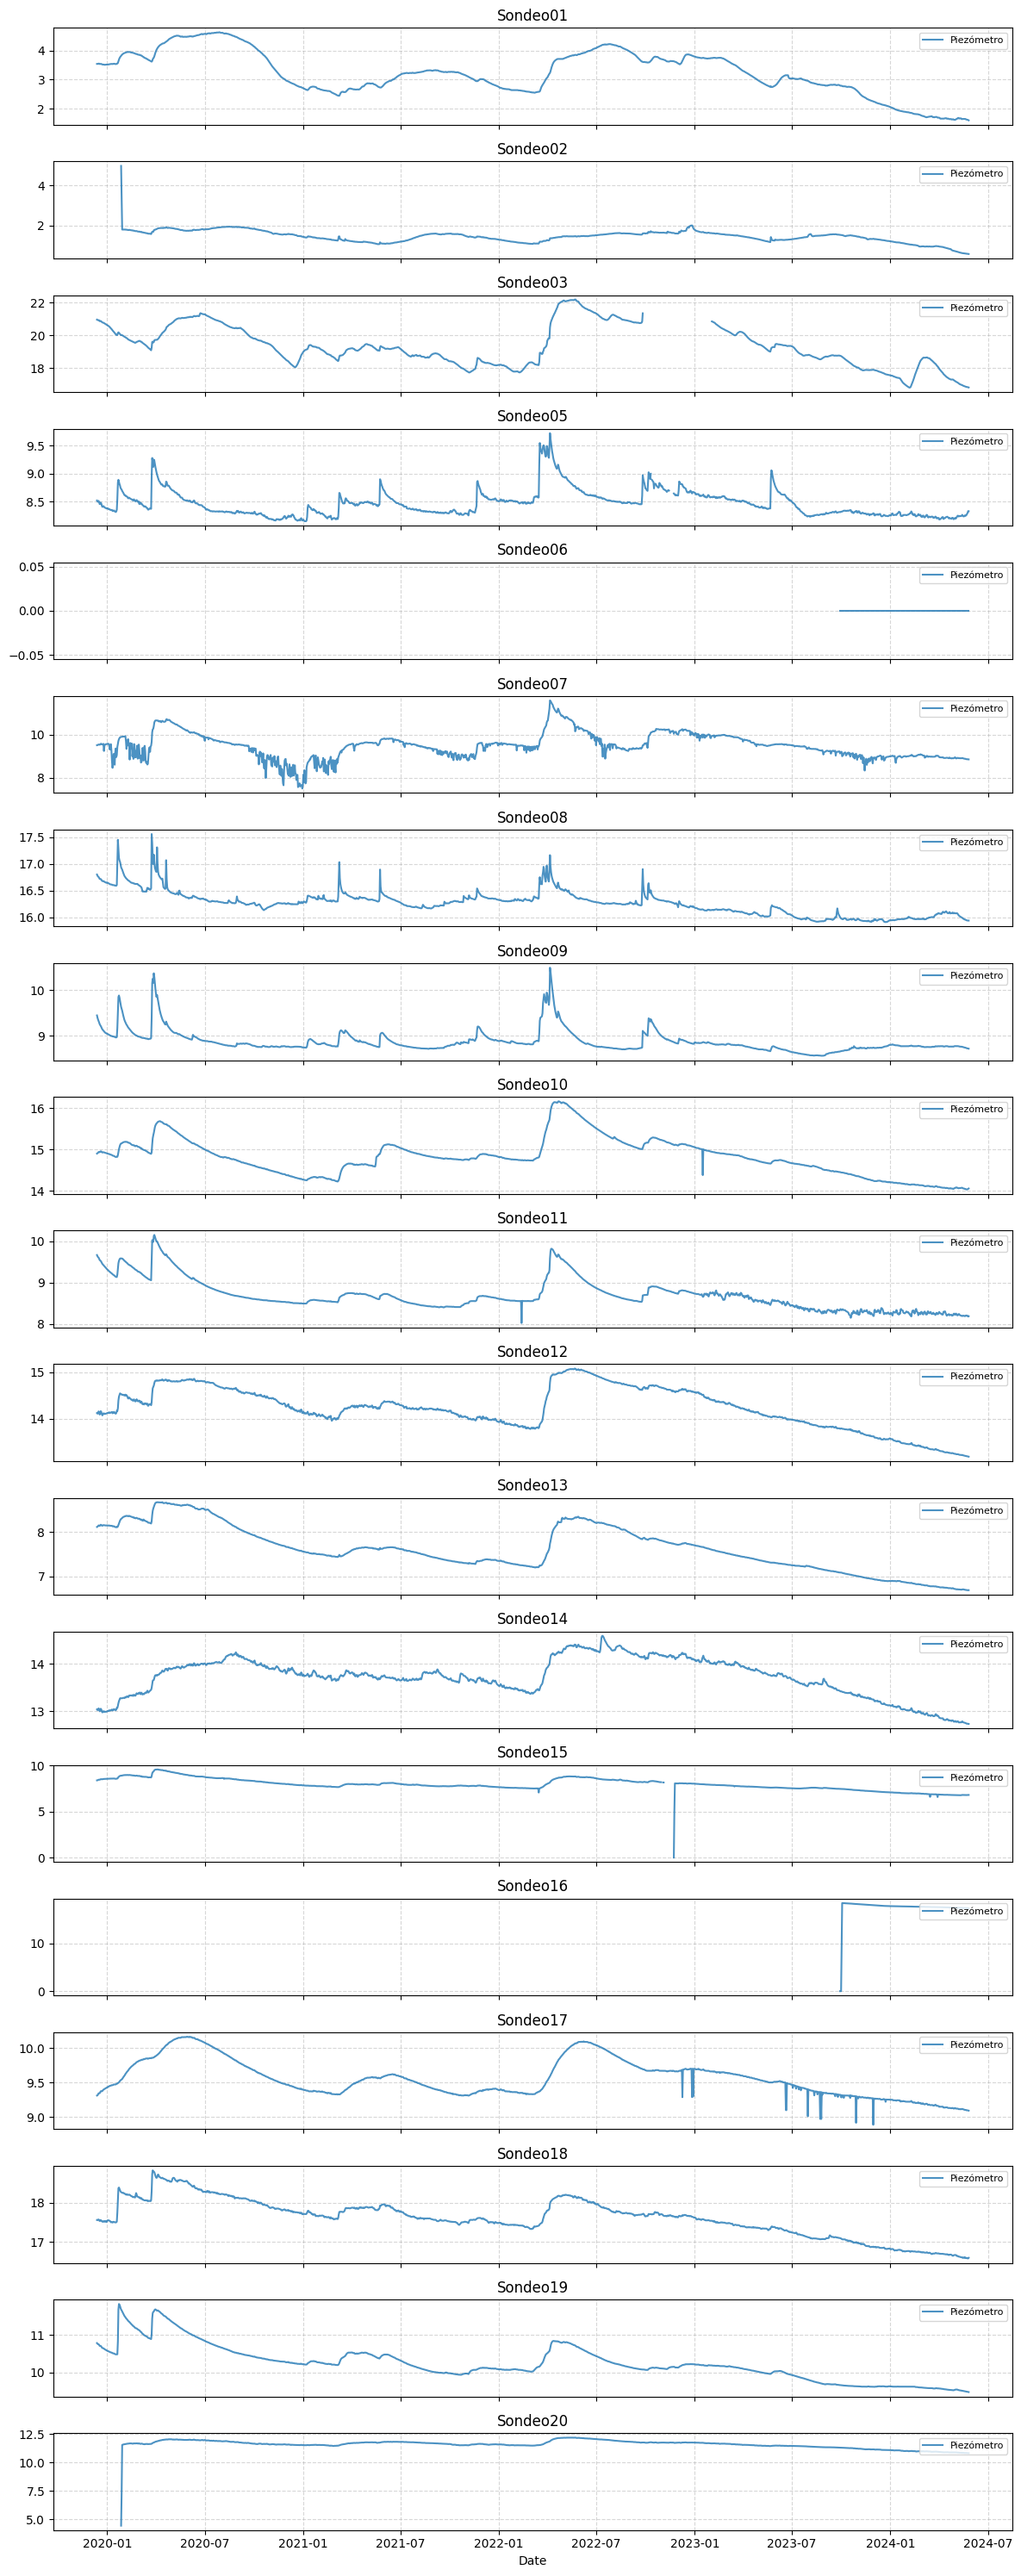

In [44]:
nrows, ncols = len(piezometros.keys()), 1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 30), sharex=True, sharey=False)

# Flatten the axes array for easier indexing
axes = axes.flatten()

for i, sondeo in enumerate(sorted(piezometros.keys())):
    ax = axes[i]

    ax.plot(piezometros[sondeo]["Date"], piezometros[sondeo]["Piezometrico"], label="Piezómetro", alpha=0.8)
    ax.set_title(f"{sondeo}")
    
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle = '--', alpha = 0.5)

ax.set_xlabel('Date')
fig.tight_layout()


Ver que aunque hay cambios que se ven bastante marcados el rango de la medida no se mueve mucho. Hay dos evenos dónde se ve una subida en muchos de los piezómetros - en torno a abril de 2021 y abril de 2022.

Las series de 02, 06, 15, 16 y 20 son constantes prácticamente y/o están incompletas.

### Agrupando por proximidad

In [71]:
piezometros = {key: df for key, df in piezometros.items() if key not in ["Sondeo06", "Sondeo16", "Sondeo15"]}

In [72]:
for key, df in piezometros.items():
    piezometros[key] = df.replace(0, np.nan)
    piezometros[key] = df.interpolate(method='linear')

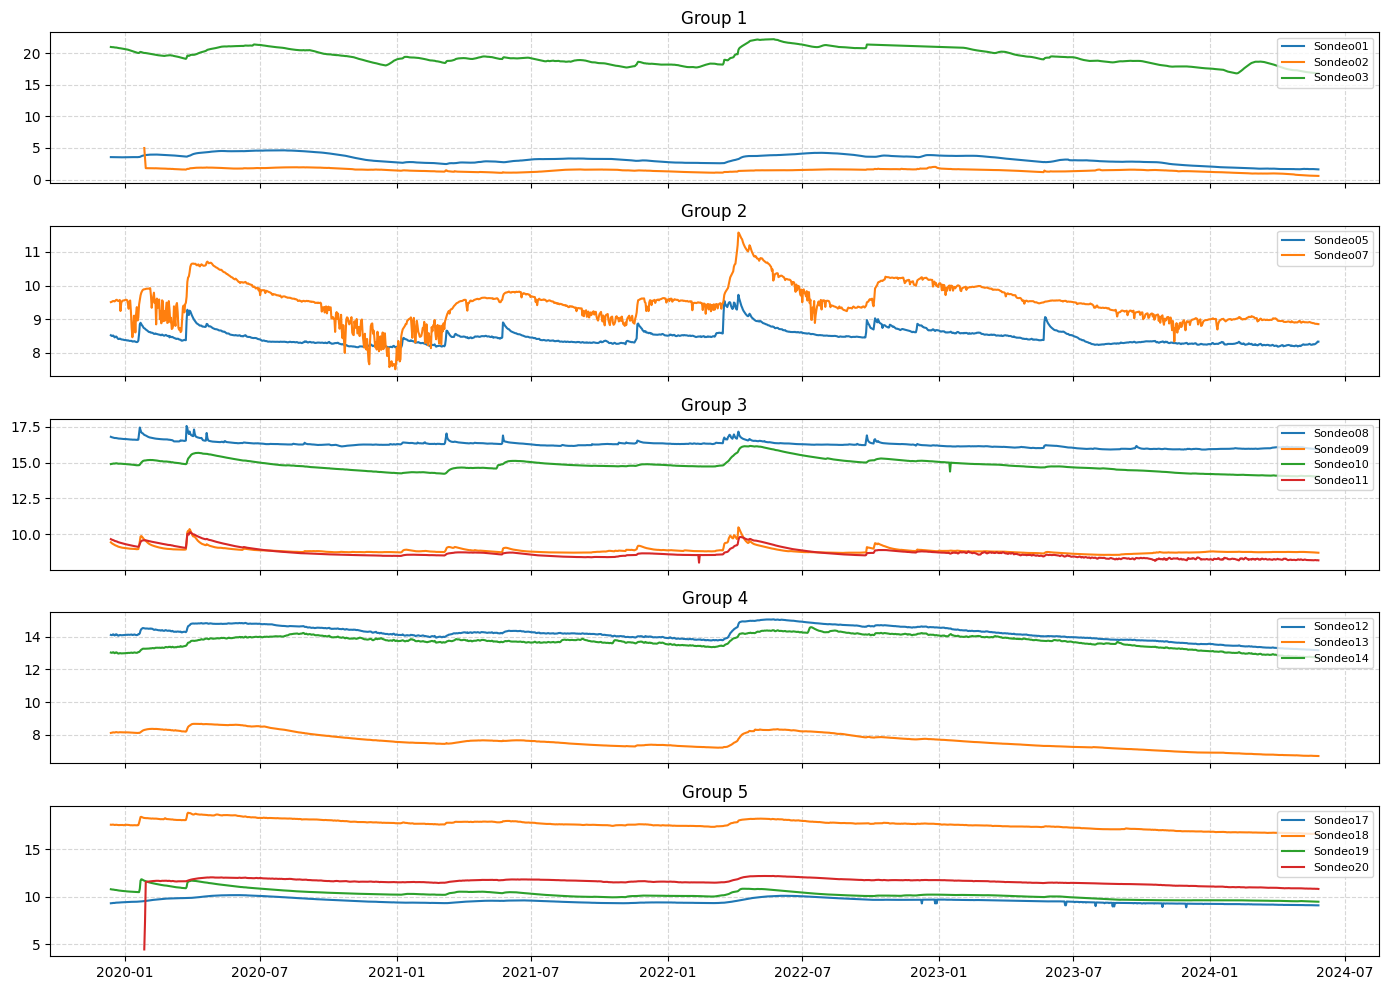

In [74]:
grouped_piezometers = {
    "Group 1": ["Sondeo01", "Sondeo02", "Sondeo03"],
    "Group 2": ["Sondeo05", "Sondeo07"],
    "Group 3": ["Sondeo08", "Sondeo09", "Sondeo10", "Sondeo11"],
    "Group 4": ["Sondeo12", "Sondeo13", "Sondeo14"],
    "Group 5": ["Sondeo17", "Sondeo18", "Sondeo19", "Sondeo20"]
}

fig, axes = plt.subplots(len(grouped_piezometers), 1, figsize=(14, 10), sharex=True)

for ax, (group_name, piezometers) in zip(axes, grouped_piezometers.items()):
    for piezometer in piezometers:
        df = piezometros[piezometer]
        ax.plot(df["Date"], df["Piezometrico"], label=piezometer)  # Replace 'Measurement' with the actual column name
    ax.set_title(group_name)
    ax.legend(loc= "upper right", fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Media de los grupos

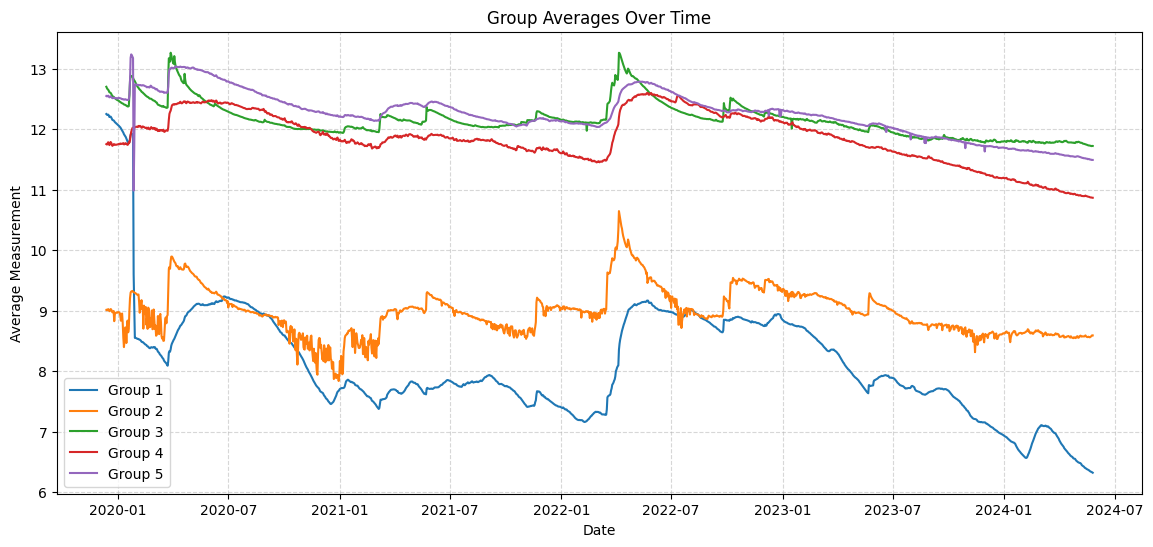

In [75]:
group_averages = {}

for group_name, piezometers in grouped_piezometers.items():
    # Extract data for each piezometer in the group
    group_data = [piezometros[piezometro].set_index("Date")["Piezometrico"] for piezometro in piezometers]
    
    # Concatenate and compute the group average
    group_avg = pd.concat(group_data, axis=1).mean(axis=1)
    group_averages[group_name] = group_avg

# Plot group averages
plt.figure(figsize=(14, 6))
for group_name, avg_series in group_averages.items():
    plt.plot(avg_series.index, avg_series, label=group_name)
    
plt.title("Group Averages Over Time")
plt.xlabel("Date")
plt.ylabel("Average Measurement")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
# Combine group_averages dictionary into a single DataFrame
combined_df = pd.concat(group_averages, axis=1)
# Rename columns to remove the multi-index structure (optional)
combined_df.columns = [f"{group}" for group in group_averages.keys()]
# Ensure Date is the index
combined_df.index.name = "Date"
combined_df.to_csv("Piezometros_groups.csv")

### Diferencia entre grupos

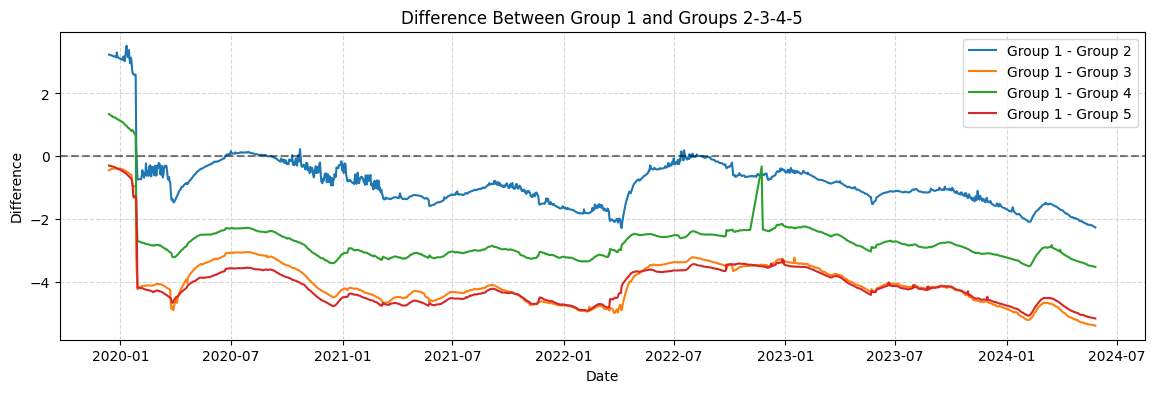

In [66]:
plt.figure(figsize=(14, 4))

group1_avg = group_averages["Group 1"]
group2_avg = group_averages["Group 2"]
group3_avg = group_averages["Group 3"]
group4_avg = group_averages["Group 4"]
group5_avg = group_averages["Group 5"]

plt.plot(group1_avg.index, group1_avg - group2_avg, label="Group 1 - Group 2")
plt.plot(group1_avg.index, group1_avg - group3_avg, label="Group 1 - Group 3")
plt.plot(group1_avg.index, group1_avg - group4_avg, label="Group 1 - Group 4")
plt.plot(group1_avg.index, group1_avg - group5_avg, label="Group 1 - Group 5")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)  # Reference line
plt.title("Difference Between Group 1 and Groups 2-3-4-5")
plt.xlabel("Date")
plt.ylabel("Difference")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


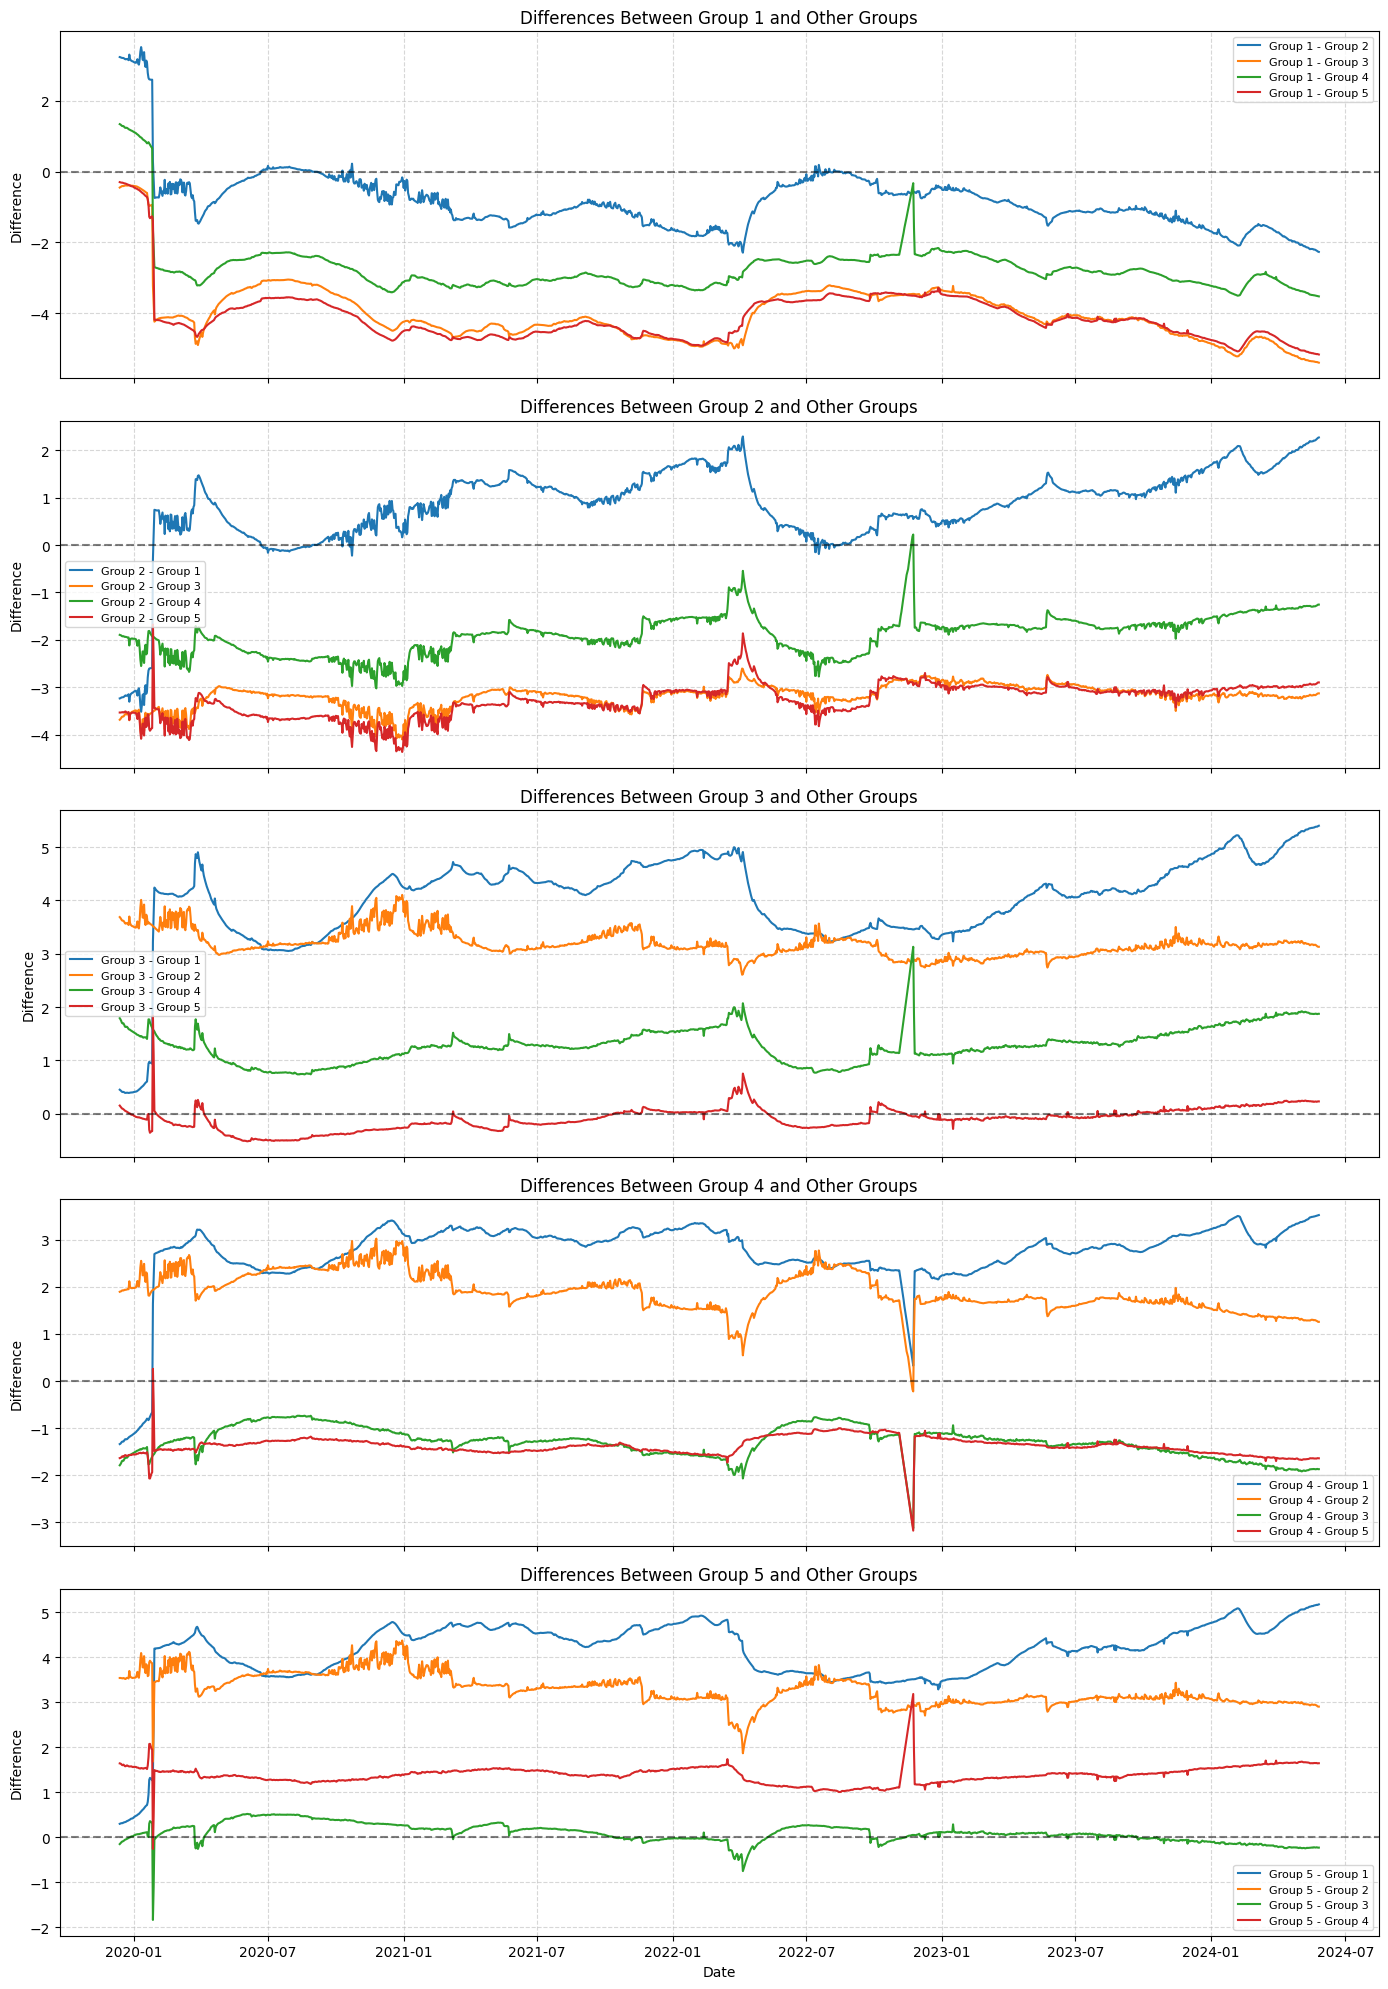

In [67]:
fig, axes = plt.subplots(len(group_averages), 1, figsize=(14, 20), sharex=True)

for i, (group_name, group_avg) in enumerate(group_averages.items()):
    ax = axes[i]
    other_groups = {key: val for key, val in group_averages.items() if key != group_name}
    
    # Plot differences between the current group and all others
    for other_name, other_avg in other_groups.items():
        ax.plot(group_avg.index, group_avg - other_avg, label=f"{group_name} - {other_name}")
    
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)  # Reference line
    ax.set_title(f"Differences Between {group_name} and Other Groups")
    ax.set_ylabel("Difference")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Date")  # Add x-axis label to the bottom subplot
plt.tight_layout()
plt.show()


In [69]:
group_pairs

[('Group 1', 'Group 2'),
 ('Group 1', 'Group 3'),
 ('Group 1', 'Group 4'),
 ('Group 1', 'Group 5'),
 ('Group 2', 'Group 3'),
 ('Group 2', 'Group 4'),
 ('Group 2', 'Group 5'),
 ('Group 3', 'Group 4'),
 ('Group 3', 'Group 5'),
 ('Group 4', 'Group 5')]

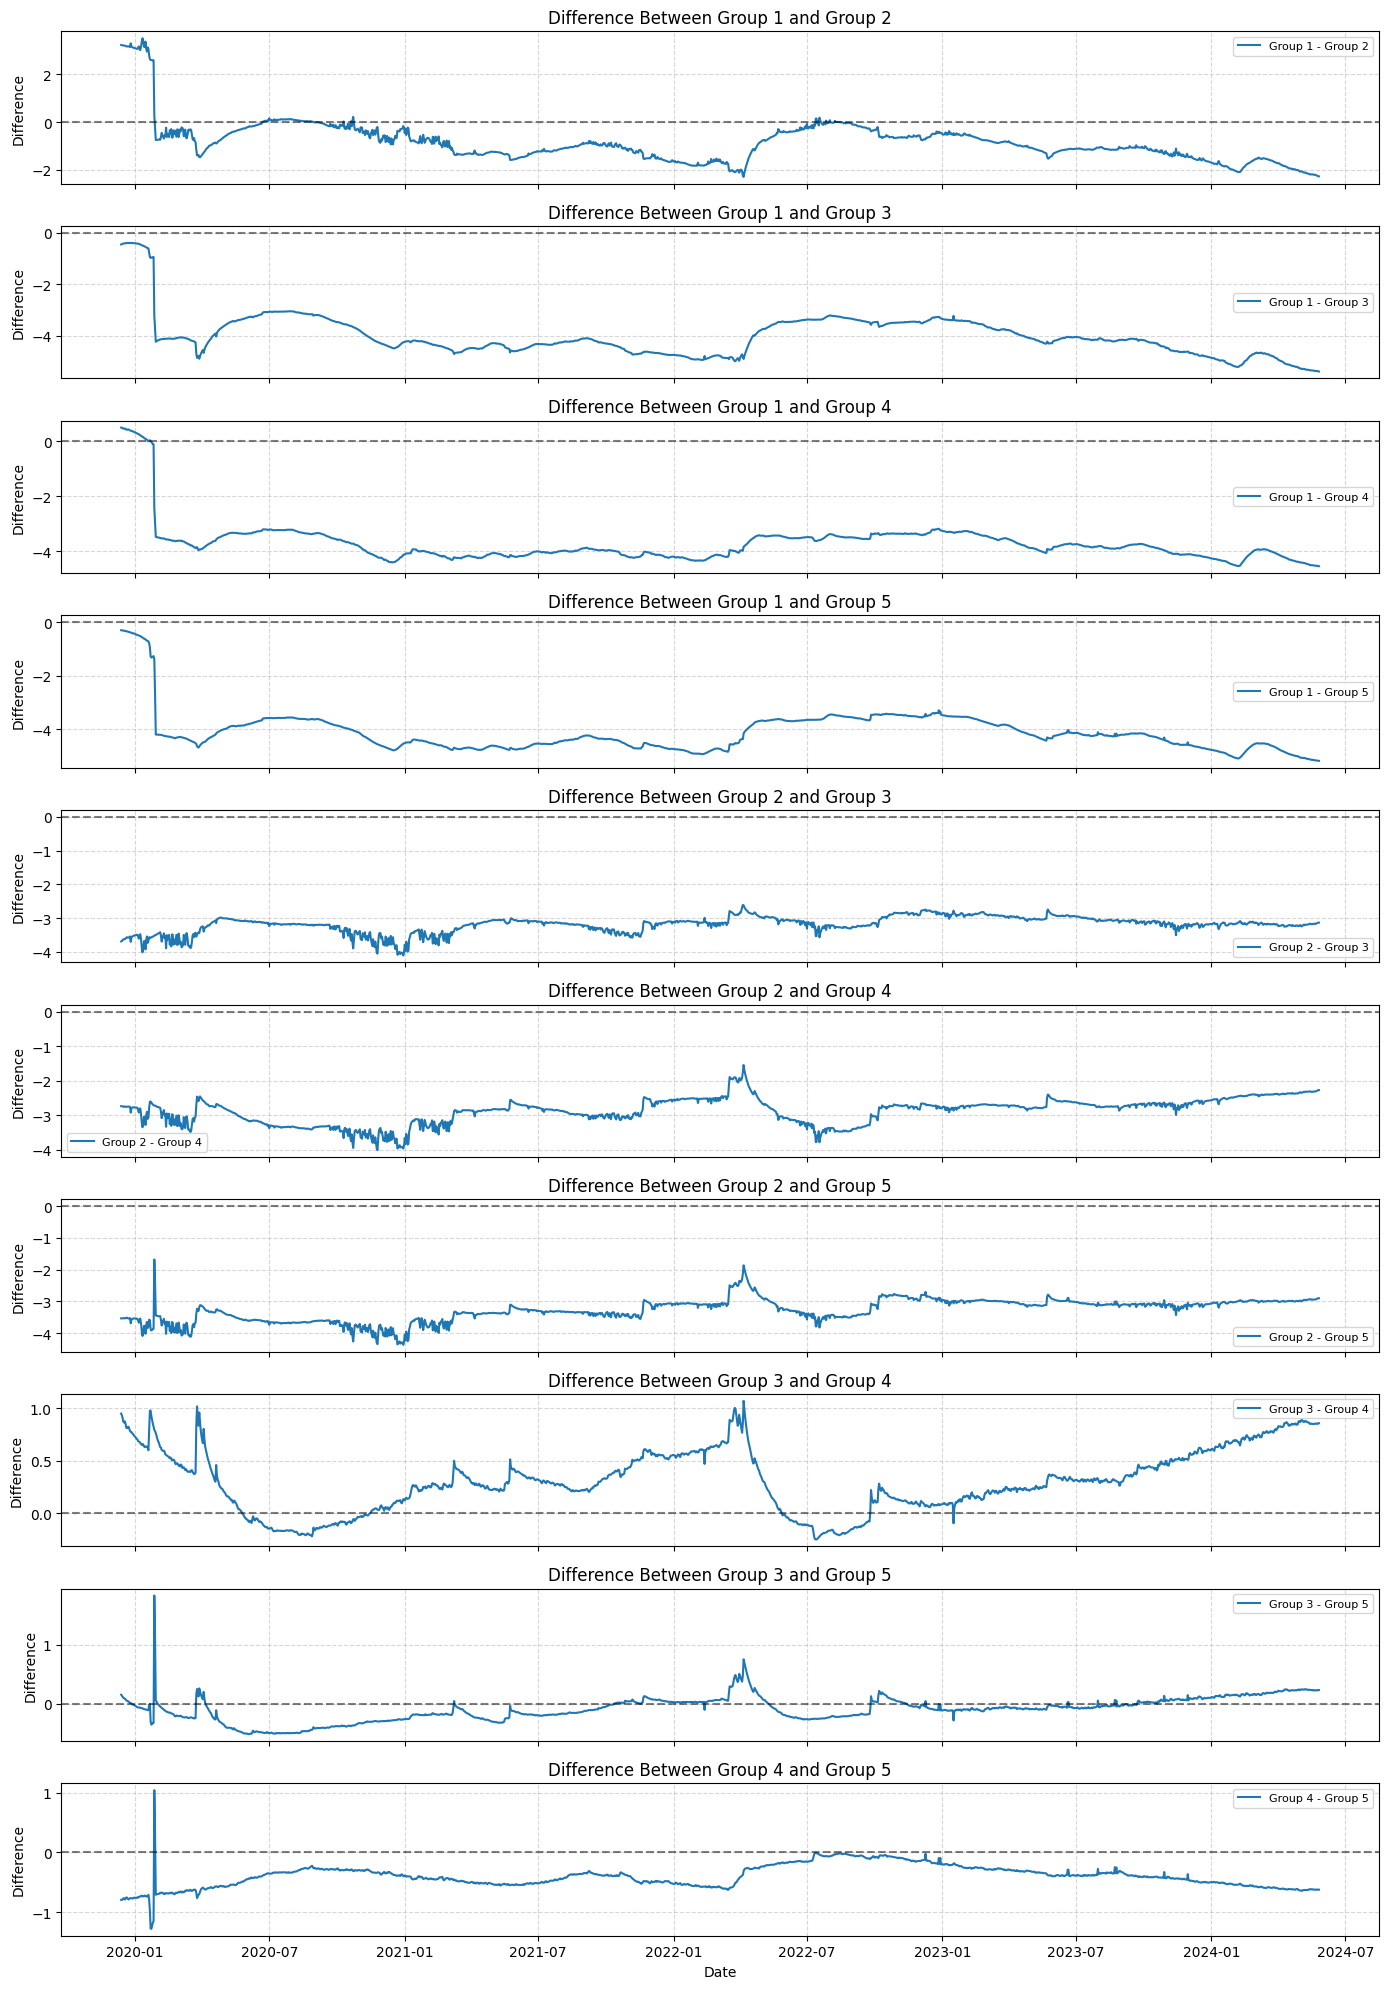

In [76]:
from itertools import combinations

# Get all unique pairs of groups
group_pairs = list(combinations(group_averages.keys(), 2))  # [(Group1, Group2), (Group1, Group3), ...]
fig, axes = plt.subplots(len(group_pairs), 1, figsize=(14, 20), sharex=True)

for i, (group1, group2) in enumerate(group_pairs):
    group1_avg = group_averages[group1]
    group2_avg = group_averages[group2]
    
    ax = axes[i]
    ax.plot(group1_avg.index, group1_avg - group2_avg, label=f"{group1} - {group2}")
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)  # Reference line
    ax.set_title(f"Difference Between {group1} and {group2}")
    ax.set_ylabel("Difference")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Date") 
plt.tight_layout()
plt.show()
